In [3]:
import os

#add the root directory
os.chdir('../')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from loader import *
import h5py
from sklearn.metrics import mean_squared_error
import seaborn as sns
import pickle
import io

from datetime import datetime

from ANN_regression import *
from torchdiffeq import odeint
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import FancyArrowPatch, Ellipse
import matplotlib.lines as mlines

from matplotlib.legend_handler import HandlerBase
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import FixedLocator, NullFormatter

<h2> Suppl. mat. S3.2 and S3.3: A posteriori simulations on different mixture fractions with H2O

Compare the PV of optimized with the optimized PV for different test trajectories.

Use the ANN closure model to construct a model that computes the PV source term given f-PV.</br> And another one to reconstruct the full state space given f-PV.

<h3> Prepare all the datasets

In [ ]:
filename_autoignition = "isochoric-adiabatic-closed-HR-H2-air-lin_Z_0.015_0.035_100-T0_900-"
path_data_autoignition = "data-files/autoignition/"
path_data = "data-files/"

regression_modelname_heuH2O = "H2O_2026-05-05_16h52_s7"
regression_full_modelname_heuH2O = "H2O_full_2026-05-05_15h00"

path_regression_model = "paper/models/"

## Define the global datasets

In [6]:
#create all the datasets
mixture_fractions_test = np.loadtxt(f"{path_data_autoignition}{filename_autoignition}mixture-fractions-test-trajectories.csv") #1 x nbr_test_trajectories
state_space_names = np.genfromtxt(f"{path_data_autoignition}{filename_autoignition}state-space-names.csv", delimiter=",", dtype=str)

<hr style="border:2px solid gray">
<h3> Sophisticated heuristic PV: H2O

In [7]:
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        return super().find_class(module, name)

with open(f'{path_regression_model}{regression_modelname_heuH2O}_metadata.pkl', 'rb') as f:
    loaded_dict = CPU_Unpickler(f).load()
    
model_params = loaded_dict["model_params"]

mins_input_heuH2O = loaded_dict["mins_input"]
maxs_input_heuH2O = loaded_dict["maxs_input"]
mins_output_heuH2O = loaded_dict["mins_output"]
maxs_output_heuH2O = loaded_dict["maxs_output"]

PV_heuH2O_source_min_train = loaded_dict["PV_Xu_source_min_train"]
log_PVsource_heuH2O = loaded_dict["log_PVsource"]
epsilon = loaded_dict["epsilon"]
Xu_H2O_heuH2O = loaded_dict["Xu_H2O"] #"Xu"
log_transform = loaded_dict["log transformation"]
scaledManifold_heuH2O = loaded_dict["scaled manifold"]

model_regression_heuH2O = ANN_regression(**model_params)
model_regression_heuH2O.load_state_dict(torch.load(f"{path_regression_model}{regression_modelname_heuH2O}_model.pth", weights_only=False, map_location=torch.device('cpu')))

def inverse_symlog(x_prime, threshold):
    return np.sign(x_prime) * threshold * (10 ** np.abs(x_prime) - 1)

C:\Windows\Temp\ipykernel_24676\2781275178.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(b), map_location='cpu')


In [8]:
prediction_test_trajectories_heuH2O = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O_heuH2O == "H2O"):
            PV_heuH2O_test = test_trajectory["H2O"]
        elif(Xu_H2O_heuH2O == "Xu"):
            PV_heuH2O_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        elif(Xu_H2O_heuH2O == "heuSoph10HO2"):
            PV_heuH2O_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        elif(Xu_H2O_heuH2O == "heuH2O"):
            PV_heuH2O_test = test_trajectory["H2O"] + test_trajectory["NO"]
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)

        if(scaledManifold_heuH2O):
            PV_heuH2O_test = (PV_heuH2O_test - PV_heuH2O_test.min())/(PV_heuH2O_test.max() - PV_heuH2O_test.min())
            #print(PV_Xu_test)

        f_PV_heuH2O_test = np.hstack((np.full(PV_heuH2O_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heuH2O_test))
        f_PV_heuH2O_test_torch = torch.tensor(f_PV_heuH2O_test)
        f_PV_heuH2O_test_torch_scaled = (f_PV_heuH2O_test_torch - mins_input_heuH2O)/(maxs_input_heuH2O - mins_input_heuH2O) - 0.5
    
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O_heuH2O == "H2O"):
            PV_heuH2O_source_test = test_trajectory_source["H2O"]
        elif(Xu_H2O_heuH2O == "Xu"):
            PV_heuH2O_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        elif(Xu_H2O_heuH2O == "heuSoph10HO2"):
            PV_heuH2O_source_test = test_trajectory_source["H2O"] + 10 * test_trajectory_source["HO2"]
        elif(Xu_H2O_heuH2O == "heuH2O"):
            PV_heuH2O_source_test = test_trajectory_source["H2O"] + test_trajectory_source["NO"]
        PV_heuH2O_source_test = PV_heuH2O_source_test.to_numpy()
    
    
    PV_heuH2O_source_test_predicted = model_regression_heuH2O(f_PV_heuH2O_test_torch_scaled)
    PV_heuH2O_source_test_predicted = (PV_heuH2O_source_test_predicted+1) /2 * (maxs_output_heuH2O - mins_output_heuH2O) + mins_output_heuH2O
    PV_heuH2O_source_test_predicted = PV_heuH2O_source_test_predicted.detach().numpy()
    if(log_PVsource_heuH2O):
        if(log_transform == "continuous-symlog"):
            PV_heuH2O_source_test_predicted = inverse_symlog(PV_heuH2O_source_test_predicted, epsilon)
        elif(log_transform == "log"):
            PV_heuH2O_source_test_predicted = 10**PV_heuH2O_source_test_predicted
    
    prediction_test_trajectories_heuH2O.append(PV_heuH2O_source_test_predicted)

    MSE_heuH2O_test = mean_squared_error(PV_heuH2O_source_test, PV_heuH2O_source_test_predicted)

    print(f"MSE of heuH2O for test trajectory {i}: {MSE_heuH2O_test}")

MSE of heuH2O for test trajectory 0: 18353234.898707483
MSE of heuH2O for test trajectory 1: 28926827.79664056
MSE of heuH2O for test trajectory 2: 42277503.76457558
MSE of heuH2O for test trajectory 3: 57748883.48935328
MSE of heuH2O for test trajectory 4: 74541252.33946808
MSE of heuH2O for test trajectory 5: 92434233.94207917
MSE of heuH2O for test trajectory 6: 110908770.11077724
MSE of heuH2O for test trajectory 7: 129088530.41203883
MSE of heuH2O for test trajectory 8: 146409995.1731565
MSE of heuH2O for test trajectory 9: 162317204.43292895


C:\Windows\Temp\ipykernel_24676\817780894.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


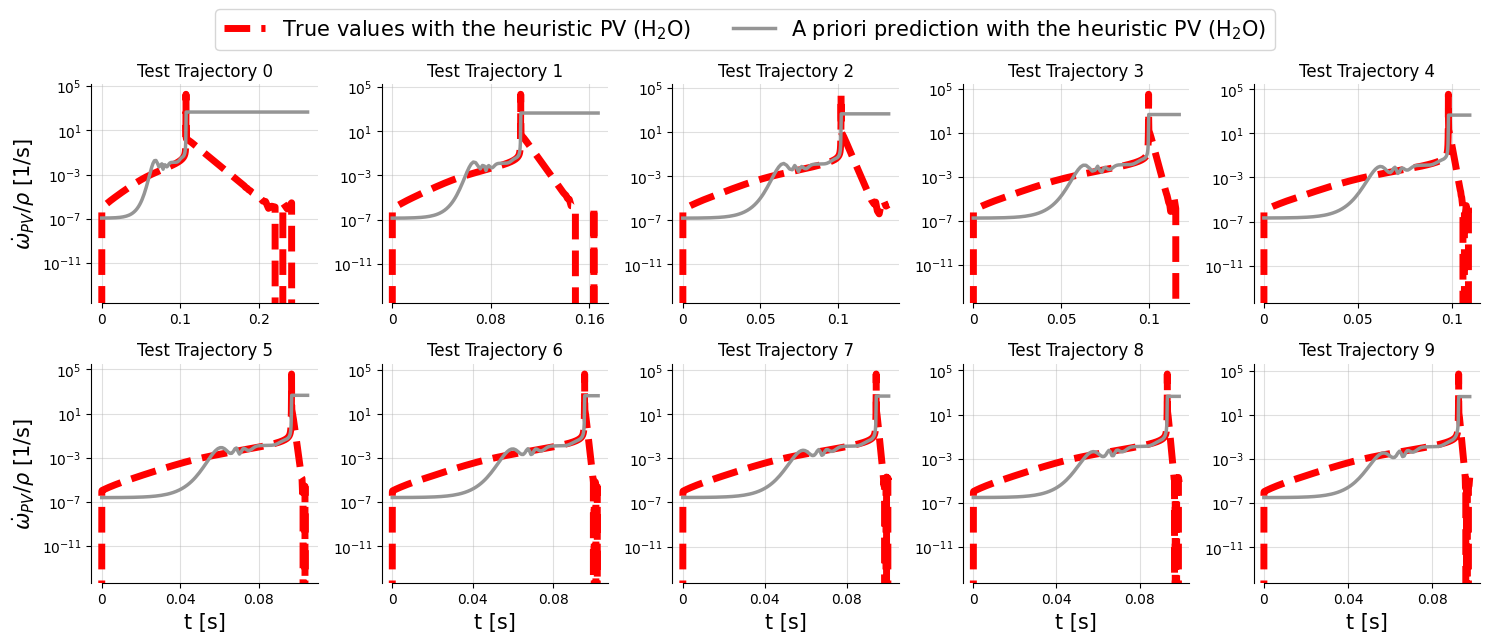

In [9]:
save = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"
name = f"Apriori_ANN_{regression_modelname_heuH2O}.png"
namePdf = f"Apriori_ANN_{regression_modelname_heuH2O}.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

greys = cm.get_cmap('Greys')

def zero_formatter(x, pos):
    if x == 0:
        return "0"
    else:
        return f"{x:g}"

for i in range(num_test_trajectories):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_source_test = test_trajectory_source["H2O"] + test_trajectory_source["NO"]
        PV_heuH2O_source_test = PV_heuH2O_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    ax = axes[i]
    ax.plot(test_trajectory_time, PV_heuH2O_source_test, label="True values with the heuristic PV (H$_2$O)", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time, prediction_test_trajectories_heuH2O[i], label="A priori prediction with the heuristic PV (H$_2$O)", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    ax.xaxis.set_major_formatter(FuncFormatter(zero_formatter))
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

In [10]:
class ODEheuH2O(torch.nn.Module):

    def __init__(self, min_max_PV):
        super().__init__()
        self.outputs = [] #list to store the predicted source terms
        self.min_PV = min_max_PV[0]
        self.max_PV = min_max_PV[1]

    def forward(self, t, y):
        
        y_scaled = y.clone() #avoid in place changes
        if scaledManifold_heuH2O:
            y_scaled[0, 1] = (y_scaled[0, 1] - self.min_PV)/(self.max_PV - self.min_PV)

        f_PV = (y_scaled-mins_input_heuH2O) / (maxs_input_heuH2O - mins_input_heuH2O) - 0.5
        PV_source_predicted = model_regression_heuH2O(f_PV)
        PV_source_predicted = (PV_source_predicted+1) /2 * (maxs_output_heuH2O - mins_output_heuH2O) + mins_output_heuH2O

        if(log_transform == "continuous-symlog"):
            PV_source_predicted = inverse_symlog(PV_source_predicted, epsilon)
        elif(log_transform == "log"):
            PV_source_predicted = 10**PV_source_predicted

        
        self.outputs.append(PV_source_predicted.detach().numpy())

        zero = torch.tensor([[0.0]], dtype=PV_source_predicted.dtype, device=PV_source_predicted.device)
        f_PV_source_predicted = torch.cat((zero, PV_source_predicted), dim=1) #add a zero for the mixture fraction

        return f_PV_source_predicted

In [11]:
idx_start_simulation = 0
list_simulations_heuH2O = []
list_predicted_PV_source_heuH2O = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Date:", date_str)
print("Hour:", time_str)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O_heuH2O == "H2O"):
            PV_heuH2O_test = test_trajectory["H2O"]
        elif(Xu_H2O_heuH2O == "Xu"):
            PV_heuH2O_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        elif(Xu_H2O_heuH2O == "heuSoph10HO2"):
            PV_heuH2O_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        elif(Xu_H2O_heuH2O == "heuH2O"):
            PV_heuH2O_test = test_trajectory["H2O"] + test_trajectory["NO"]

        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        f_PV_heuH2O_test = np.hstack((np.full(PV_heuH2O_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heuH2O_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_heuH2O_test[idx_start_simulation,:]
    initial_condition = torch.tensor(initial_condition).unsqueeze(0)

    t_coordinates = test_trajectory_time[idx_start_simulation:].to_numpy().ravel()
    t_coordinates = torch.tensor(t_coordinates)
    
    ODEXu_instance = ODEheuH2O([PV_heuH2O_test.min(), PV_heuH2O_test.max()])
    numerical_solution_heuH2O = odeint(ODEXu_instance, initial_condition, t_coordinates) #, method="rk4")
    numerical_solution_heuH2O = numerical_solution_heuH2O.squeeze(1)
    list_simulations_heuH2O.append(numerical_solution_heuH2O)
    list_predicted_PV_source_heuH2O.append(ODEXu_instance.outputs)

    MSE_heuH2O_test_simulation = mean_squared_error(PV_heuH2O_test[idx_start_simulation:], numerical_solution_heuH2O[:,1].detach().numpy())

    print(f"MSE for test trajectory {i}: {MSE_heuH2O_test_simulation}")

Date: 2026-05-20
Hour: 12h46
MSE for test trajectory 0: 0.010012045106309339
MSE for test trajectory 1: 0.011895334746535516
MSE for test trajectory 2: 0.013730275294739804
MSE for test trajectory 3: 0.015599374443758975
MSE for test trajectory 4: 0.017445763883432205
MSE for test trajectory 5: 0.019200174563219007
MSE for test trajectory 6: 0.020823681278932613
MSE for test trajectory 7: 0.022283365792716767
MSE for test trajectory 8: 0.02358281550845162
MSE for test trajectory 9: 0.0247563482122059


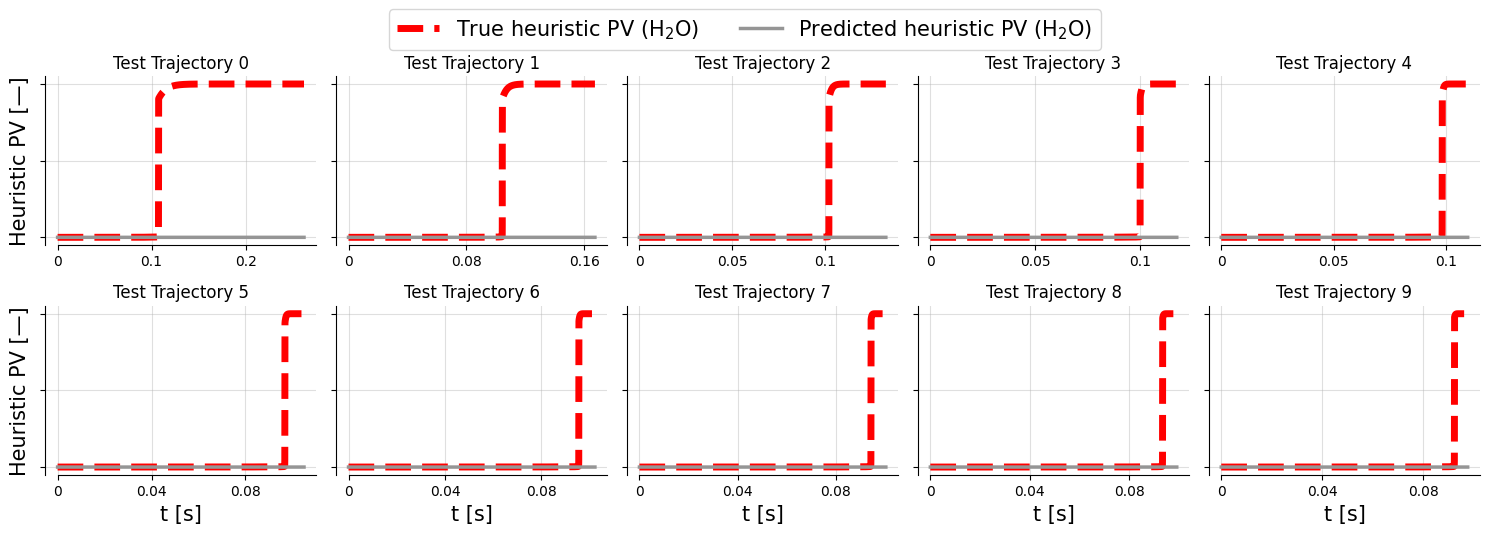

In [12]:
save = False
zoom = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"

idx_start_simulation = 0

num_test_trajectories = 10
rows, cols = 2, 5 # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

def zero_formatter(x, pos):
    if x == 0:
        return "0"
    else:
        return f"{x:g}"

for i in range(num_test_trajectories):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_test = test_trajectory["H2O"] + test_trajectory["NO"]
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        #PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())
        f_PV_heuH2O_test = np.hstack((np.full(PV_heuH2O_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heuH2O_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]

    PV_heuH2O_test_min = PV_heuH2O_test.min()
    PV_heuH2O_test_max = PV_heuH2O_test.max()

    if(zoom):
        ##############################################
        # Get the first and last index of the ignition
        ##############################################

        H2O_array = test_trajectory["H2O"].to_numpy()

        min_perc = 0.003
        max_perc = 0.995
        
        max_val = H2O_array.max()
        lower_threshold = min_perc * max_val
        upper_threshold = max_perc * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], (PV_heuH2O_test[idx_1:idx_99] - PV_heuH2O_test_min)/(PV_heuH2O_test_max - PV_heuH2O_test_min), label="True heuristic PV (H$_2$O)", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_1:idx_99], (list_simulations_heuH2O[i][idx_1:idx_99,1] - PV_heuH2O_test_min)/(PV_heuH2O_test_max - PV_heuH2O_test_min), label="Predicted heuristic PV (H$_2$O)", color = greys(0.5), linewidth = 2.5)

    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], (PV_heuH2O_test[idx_start_simulation:] - PV_heuH2O_test_min)/(PV_heuH2O_test_max - PV_heuH2O_test_min), label="True heuristic PV (H$_2$O)", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_heuH2O[i][:,1].detach().numpy() - PV_heuH2O_test_min)/(PV_heuH2O_test_max - PV_heuH2O_test_min), label="Predicted heuristic PV (H$_2$O)", color = greys(0.5), linewidth = 2.5)
    
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    ax.xaxis.set_major_formatter(FuncFormatter(zero_formatter))
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Heuristic PV [\u2014]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

name = f"Heuristic vs optimized - A posteriori - Heuristic PV heuH2O  - ANN {regression_modelname_heuH2O}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.png"
namePdf = f"Heuristic vs optimized - A posteriori - Heuristic PV heuH2O - ANN {regression_modelname_heuH2O}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.pdf"

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

In [13]:
list_simulations_heuH2O_ext = []
list_predicted_PV_source_heuH2O_ext = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Date:", date_str)
print("Hour:", time_str)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O_heuH2O == "H2O"):
            PV_heuH2O_test = test_trajectory["H2O"]
        elif(Xu_H2O_heuH2O == "Xu"):
            PV_heuH2O_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        elif(Xu_H2O_heuH2O == "heuSoph10HO2"):
            PV_heuH2O_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        elif(Xu_H2O_heuH2O == "heuH2O"):
            PV_heuH2O_test = test_trajectory["H2O"] + test_trajectory["NO"]
        
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        f_PV_heuH2O_test = np.hstack((np.full(PV_heuH2O_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heuH2O_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_heuH2O_test[0,:]
    initial_condition = torch.tensor(initial_condition).unsqueeze(0)

    t_coordinates = test_trajectory_time[0:].to_numpy().ravel()
    t_coordinates = torch.tensor(t_coordinates)
    deltaTime = t_coordinates[-1] - t_coordinates[-2]

    last_value = t_coordinates[-1]
    new_times = []

    next_time = last_value + deltaTime
    while next_time <= 2:
        new_times.append(next_time.item())
        next_time += deltaTime

    #Add extension to the current tensor
    if new_times:
        extension = torch.tensor(new_times, dtype=torch.float32)
        t_coordinates = torch.cat((t_coordinates, extension))
    
    ODEXu_instance = ODEheuH2O([PV_heuH2O_test.min(), PV_heuH2O_test.max()])
    numerical_solution_heuH2O = odeint(ODEXu_instance, initial_condition, t_coordinates) #, method="rk4")
    numerical_solution_heuH2O = numerical_solution_heuH2O.squeeze(1)
    list_simulations_heuH2O_ext.append(numerical_solution_heuH2O)
    list_predicted_PV_source_heuH2O_ext.append(ODEXu_instance.outputs)

Date: 2026-05-20
Hour: 12h46


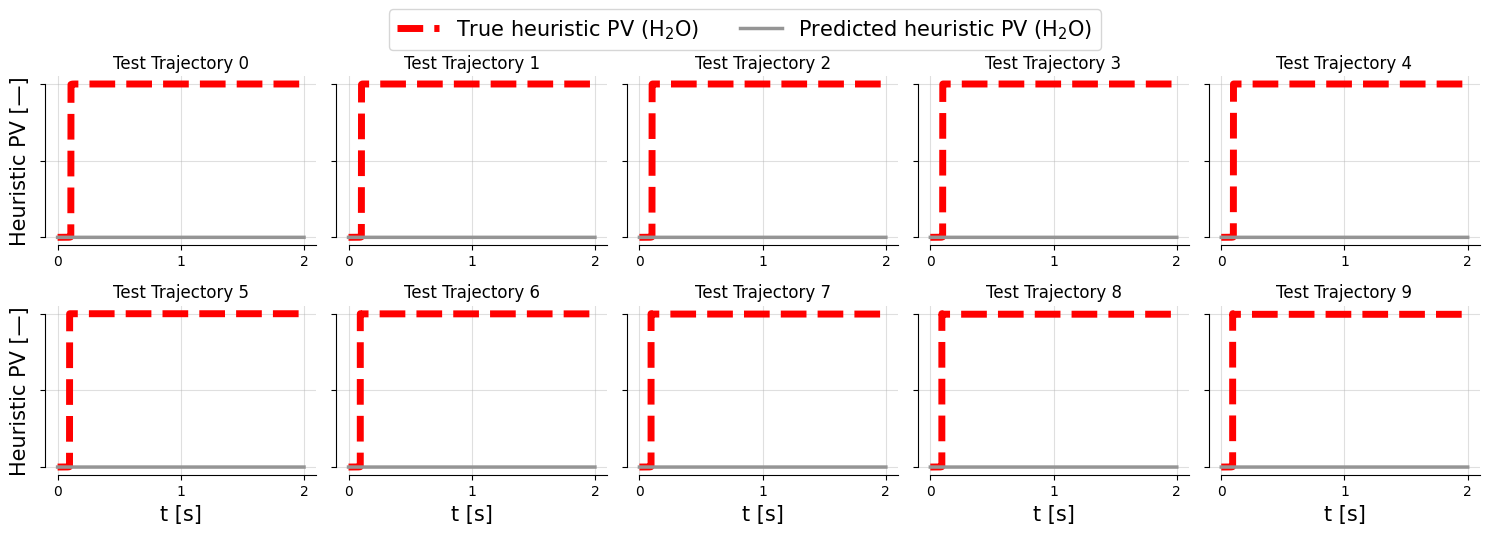

In [14]:
save = False
zoom = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"
name = f"Heuristic vs optimized - A posteriori - Heuristic PV heuH2O - ANN {regression_modelname_heuH2O}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}_timeExt.png"
namePdf = f"Heuristic vs optimized - A posteriori - Heuristic PV heuH2O - ANN {regression_modelname_heuH2O}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}_timeExt.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O_heuH2O == "H2O"):
            PV_heuH2O_test = test_trajectory["H2O"]
        elif(Xu_H2O_heuH2O == "Xu"):
            PV_heuH2O_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        elif(Xu_H2O_heuH2O == "heuSoph10HO2"):
            PV_heuH2O_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        elif(Xu_H2O_heuH2O == "heuH2O"):
            PV_heuH2O_test = test_trajectory["H2O"] + test_trajectory["NO"]
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        f_PV_heuH2O_test = np.hstack((np.full(PV_heuH2O_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heuH2O_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
    
    test_trajectory_time = test_trajectory_time.to_numpy().ravel()
    test_trajectory_time = torch.tensor(test_trajectory_time)
    deltaTime = test_trajectory_time[-1] - test_trajectory_time[-2]

    last_value = test_trajectory_time[-1]
    new_times = []

    next_time = last_value + deltaTime
    while next_time <= 2:
        new_times.append(next_time.item())
        next_time += deltaTime

    #Add extension to the current tensor
    if new_times:
        extension = torch.tensor(new_times, dtype=torch.float32)
        test_trajectory_time_ext = torch.cat((test_trajectory_time, extension))

        last_value = PV_heuH2O_test[-1]
        extension = np.tile(last_value, (len(new_times), 1))  #extension with last value of PV_Xu_test
        PV_heuH2O_test_ext = np.vstack((PV_heuH2O_test, extension)) #concatenate the extension with the original value

    min_PV_heuH2O = PV_heuH2O_test_ext.min()
    max_PV_heuH2O = PV_heuH2O_test_ext.max()

    ax = axes[i]
    ax.plot(test_trajectory_time_ext, (PV_heuH2O_test_ext-min_PV_heuH2O)/(max_PV_heuH2O - min_PV_heuH2O), label="True heuristic PV (H$_2$O)", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time_ext, (list_simulations_heuH2O_ext[i][:,1].detach().numpy()-min_PV_heuH2O)/(max_PV_heuH2O - min_PV_heuH2O), label="Predicted heuristic PV (H$_2$O)", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    ax.spines["left"].set_bounds(0, 1)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Heuristic PV [\u2014]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()